### Football 

# Task 1:
1)import pandas and read the csv file
##
2)show the first 5 rows of the dataset
## 
3)change "date" to datetime from object


In [10]:
import pandas as pd
import matplotlib as plt
import numpy as np

df=pd.read_csv("results.csv")

In [2]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [7]:
# df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49520 non-null  object 
 1   home_team   49520 non-null  object 
 2   away_team   49520 non-null  object 
 3   home_score  49518 non-null  float64
 4   away_score  49518 non-null  float64
 5   tournament  49520 non-null  object 
 6   city        49520 non-null  object 
 7   country     49520 non-null  object 
 8   neutral     49520 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [8]:
#converting "date" into datetime from string/object
df['date']=pd.to_datetime(df['date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49520 non-null  datetime64[ns]
 1   home_team   49520 non-null  object        
 2   away_team   49520 non-null  object        
 3   home_score  49518 non-null  float64       
 4   away_score  49518 non-null  float64       
 5   tournament  49520 non-null  object        
 6   city        49520 non-null  object        
 7   country     49520 non-null  object        
 8   neutral     49520 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(5)
memory usage: 3.1+ MB


# Task 2:
1)Create total goals coloumn tht shows the sum of home and away goals
## 
2)Filter the data to only show matches where the tournament column is exactly 'FIFA World Cup'
## 

In [14]:
df["Total_goals"]=df["home_score"]+df["away_score"]

In [15]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Total_goals
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,6.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,3.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,4.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3.0


In [21]:
df['tournament'].values

array(['Friendly', 'Friendly', 'Friendly', ..., 'FIFA World Cup',
       'FIFA World Cup', 'FIFA World Cup'], shape=(49520,), dtype=object)

In [23]:
worldcup_df=df[df["tournament"]=="FIFA World Cup"]

In [24]:
worldcup_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Total_goals
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,3.0
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True,5.0
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True,3.0
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,4.0
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True,1.0


## Task 3:

##
 Find the match in your new world_cup_df that has the absolute highest number of Total_goals.
##

In [27]:
worldcup_df.sort_values(by="Total_goals",ascending=False).head(1)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Total_goals
3975,1954-06-26,Switzerland,Austria,5.0,7.0,FIFA World Cup,Lausanne,Switzerland,False,12.0


## Task 4: Total Dominance (Value Counts)
##
Find out which stadium city has hosted the most international football matches in history.
##

In [28]:
df["city"].value_counts()

city
Kuala Lumpur          745
Bangkok               580
Doha                  560
London                453
Budapest              437
                     ... 
Bonneuil-sur-Marne      1
Cremona                 1
Maladzyechna            1
Danlí                   1
Chapel Hill             1
Name: count, Length: 2092, dtype: int64

In [29]:
df.value_counts(df['city'])

city
Kuala Lumpur    745
Bangkok         580
Doha            560
London          453
Budapest        437
               ... 
Añasco            1
Gangtok           1
Gama              1
Aarau             1
Šibenik           1
Name: count, Length: 2092, dtype: int64

## Task 5: High-Scoring Tournaments (Grouping)
##
Calculate the average total goals scored per match for each type of tournament.

##

In [32]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'Total_goals'],
      dtype='object')

In [ ]:
df.groupby("tournament")["Total_goals"].mean().sort_values(ascending=False)

tournament
FIFA 75th Anniversary Cup                                   0.000000
ASEAN Championship qualification                            0.500000
Al Ain International Cup                                    1.000000
CONIFA Africa Football Cup                                  1.250000
Matthews Cup                                                1.250000
                                                              ...   
Évence Coppée Trophy                                        6.000000
Tri-Nations Cup                                             6.500000
Inter-Allied Games                                          6.692308
East Asian Games                                            7.235294
International Tournament of Peoples, Cultures and Tribes    9.857143
Name: Total_goals, Length: 201, dtype: float64

## Task 6: Era Analysis (Filtering by Year)
##
Create a filtered DataFrame called modern_era_df that only contains matches played from 
the year 2000 onwards.
##

In [35]:
modern_footie=df[df["date"]>='2000-01-01']

In [36]:
modern_footie.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Total_goals
24062,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,3.0
24063,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,7.0
24064,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,0.0
24065,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False,2.0
24066,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True,2.0


## Task 7:
##
Calculate the average total goals for matches played in June vs. matches played in December.
##

In [44]:
# modern_footie['date']=pd.to_datetime(modern_footie['date'])
modern_footie['date'] = pd.to_datetime(modern_footie['date'])

C:\Users\anass\AppData\Local\Temp\ipykernel_28232\1489175329.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modern_footie['date'] = pd.to_datetime(modern_footie['date'])


In [46]:
# modern_footie[modern_footie['date'].dt.month == 6]
modern_footie[modern_footie['date'].dt.month == 6]['Total_goals'].mean()

np.float64(2.8216021982667514)

In [47]:
modern_footie[modern_footie['date'].dt.month==12]["Total_goals"].mean()

np.float64(2.8373764600179694)

## Task 8: The Home Advantage Calculation
## 
Find the average number of goals scored by the home team vs. the away team across the entire dataset.
##

In [48]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'Total_goals'],
      dtype='object')

In [56]:
print("home score avg:",df["home_score"].mean())
print("away score avg:",df["away_score"].mean())

home score avg: 1.757179207560887
away score avg: 1.1823377357728502


In [59]:
neutral_df=df[df["neutral"]==True]
true_home_df=df[df["neutral"]==False]

In [62]:
print("home score avg:",neutral_df["home_score"].mean())
print("away score avg:",neutral_df["away_score"].mean())

home score avg: 1.6702904059601642
away score avg: 1.3709137904819826


In [63]:
print("home score avg :",true_home_df["home_score"].mean())
print("away score avg :",true_home_df["away_score"].mean())

home score avg : 1.788609613903861
away score avg : 1.1141238587614124


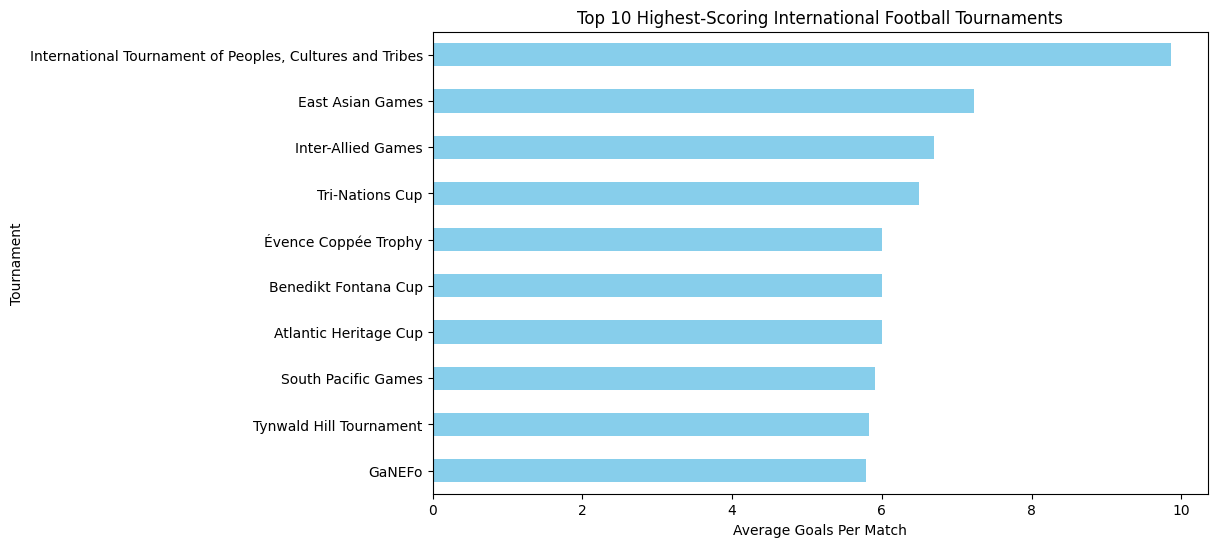

In [ ]:
import matplotlib.pyplot as plt
top_tournaments = df.groupby("tournament")["Total_goals"].mean().sort_values(ascending=False).head(10)
top_tournaments.plot(kind='barh', color='skyblue', figsize=(10, 6))

plt.title('Top 10 Highest-Scoring International Football Tournaments')
plt.xlabel('Average Goals Per Match')
plt.ylabel('Tournament')
plt.gca().invert_yaxis() 
plt.show()